<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #1e3a8a; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Paradigmas de Aprendizaje 🧭
      </h1>
      <p style="margin: 6px 0 0 0; color: #1e3a8a; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Machine Learning
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #1e3a8a; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 00
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #2563eb; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>

<div align="center" style="margin-top: 15px; margin-bottom: 15px;">
  <a href="https://colab.research.google.com/github/sazuniga06/Data-Science-Programming---USTA-Tunja-Repository/blob/main/Machine%20Learning/00%20-%20Introduccion%20al%20Machine%20Learning/01_Paradigmas_de_Aprendizaje.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab" style="vertical-align: middle;"/>
  </a>
</div>

---
## Objetivos de Aprendizaje 🔎

Este cuaderno desarrolla la **Sección 1.4 (Conceptos generales)** del Capítulo 1 y responde a la pregunta *¿de cuántas maneras distintas puede aprender una máquina?* Cubre:

- **1.4.1 Aprendizaje supervisado**
- **1.4.2 Aprendizaje no supervisado**
- **1.4.3 Aprendizaje por refuerzo**
- Mención de los paradigmas híbridos: **semi-supervisado** y **auto-supervisado**.

Al terminar podrás:

1. **Formalizar** cada paradigma indicando qué datos recibe, qué señal de aprendizaje usa y qué objetivo optimiza.
2. **Implementar** una demo mínima de cada uno: un clasificador *k*-NN (supervisado), *K-Means* sobre *blobs* (no supervisado) y un **bandido multibrazo $\varepsilon$-greedy** en NumPy puro (refuerzo).
3. **Elegir** el paradigma adecuado a partir de la disponibilidad de etiquetas y de la naturaleza del problema.
4. **Comparar** los paradigmas con una tabla de datos, señal de aprendizaje, objetivo, ejemplos y métricas.

> 📍 **Dónde estamos:** Módulo 00, cuaderno 1 de 3 (después de [Introducción y Panorama del ML](00_Introduccion_y_Panorama_del_ML.ipynb)).

---
## Recursos Recomendados 📚

### 📖 Libros de Referencia:
- *Hands-On Machine Learning with Scikit-Learn and PyTorch* — **Aurélien Géron** (O'Reilly, 2025). Cap. 1, sección *Types of Machine Learning Systems* (disponible en `Machine Learning/Libros/`).
- *Python Machine Learning* — **Sebastian Raschka** (Packt). Cap. 1, sección *Three different types of machine learning* (disponible en `Machine Learning/Libros/`).
- *Machine Learning For Dummies* (2.ª ed.) — **John Paul Mueller & Luca Massaron** (Wiley, 2021).
- *Reinforcement Learning: An Introduction* (2.ª ed., 2018) — **Richard S. Sutton & Andrew G. Barto** (acceso libre en la web de los autores). Fuente del *testbed* de 10 brazos usado en este cuaderno.
- *The Elements of Statistical Learning* — **Hastie, Tibshirani & Friedman**. Formalización del riesgo y la minimización del riesgo empírico.

### 🌐 Documentación y Recursos Online:
- [scikit-learn: Supervised learning](https://scikit-learn.org/stable/supervised_learning.html)
- [scikit-learn: Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- [scikit-learn: Semi-supervised learning](https://scikit-learn.org/stable/modules/semi_supervised.html)
- [Documentación de NumPy](https://numpy.org/doc/stable/)

---
## 1. Panorama de los Paradigmas (1.4) 🗺️

Un **paradigma de aprendizaje** queda definido por **qué información recibe el algoritmo** durante el entrenamiento. La pregunta que lo distingue es: *¿qué tipo de retroalimentación hay disponible?*

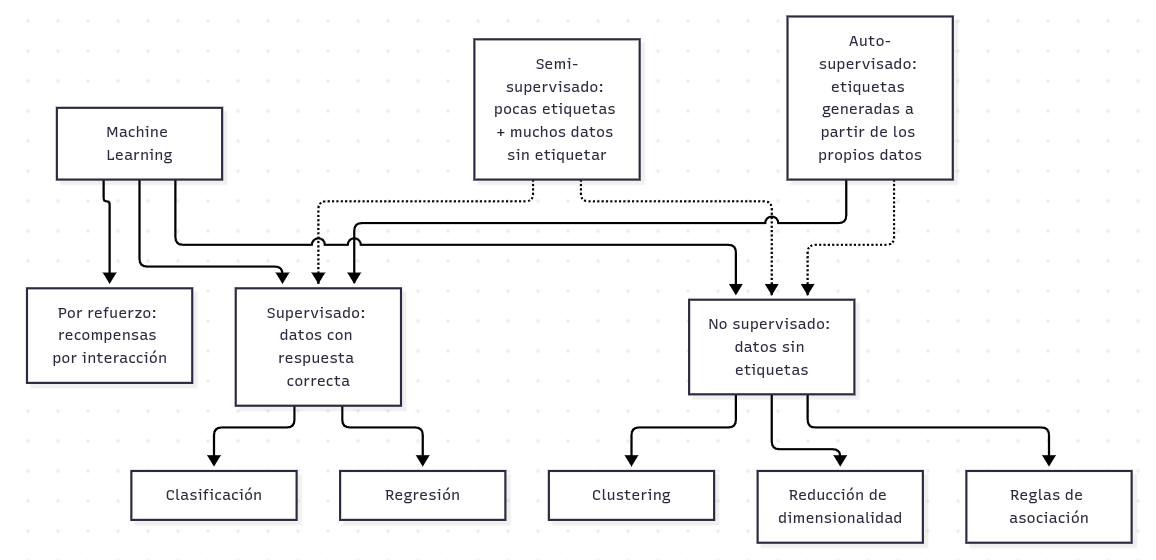

| Pregunta | Paradigma |
|---|---|
| ¿Tengo ejemplos con la respuesta correcta anotada? | **Supervisado** |
| ¿Solo tengo las características y quiero descubrir estructura? | **No supervisado** |
| ¿Un agente actúa en un entorno y recibe recompensas por sus decisiones? | **Por refuerzo** |

> 🔗 En la [Taxonomía de Tareas de Data Mining](../../Data%20Mining/00%20-%20Introduccion%20al%20Data%20Mining/02_Taxonomia_de_Tareas_en_Mineria_de_Datos.ipynb) esta misma división aparece como tareas *predictivas* vs. *descriptivas*. Aquí la miramos desde el punto de vista del **aprendizaje** y de la **señal** que recibe el algoritmo; el refuerzo no aparece allí porque no es una tarea de minería sobre datos estáticos.

---
## 2. Aprendizaje Supervisado (1.4.1) 🎓

### Formalización

Disponemos de un conjunto de entrenamiento de $n$ pares **(entrada, respuesta)**:

$$\mathcal{D} = \{(x_i, y_i)\}_{i=1}^{n}, \qquad x_i \in \mathcal{X}, \; y_i \in \mathcal{Y}$$

que suponemos generados de forma independiente por una distribución desconocida $P(X, Y)$. El objetivo es hallar una función $f: \mathcal{X} \to \mathcal{Y}$ que prediga bien la respuesta de entradas **nuevas**. Con una función de pérdida $\ell$, el **riesgo** (error esperado) y el **riesgo empírico** son:

$$R(f) = \mathbb{E}_{(X,Y)\sim P}\big[\ell(f(X), Y)\big], \qquad \hat{R}(f) = \frac{1}{n}\sum_{i=1}^{n} \ell\big(f(x_i), y_i\big)$$

Como $P$ es desconocida, no podemos calcular $R(f)$; en su lugar se aplica la **minimización del riesgo empírico**, $\hat{f} = \arg\min_{f \in \mathcal{H}} \hat{R}(f)$, y se **estima** $R$ con datos que no se usaron para entrenar (conjunto de prueba o validación cruzada). Si $\hat{R}$ es bajo pero $R$ estimado es alto, el modelo **sobreajusta** (*overfitting*).

| Variante | Espacio de salida $\mathcal{Y}$ | Pérdida típica | Ejemplo |
|---|---|---|---|
| **Clasificación** | Conjunto finito de clases | Pérdida 0-1, entropía cruzada | Spam / no spam |
| **Regresión** | Números reales | Error cuadrático $(f(x)-y)^2$ | Precio de una vivienda |

**Ejemplo canónico:** un filtro de spam entrenado con correos que los usuarios ya marcaron como *spam* o *ham*.

### Demo: un clasificador simple sobre Iris

Usamos el clásico dataset *Iris* (Fisher, 1936: 150 flores de 3 especies) con solo dos variables para poder **dibujar** la frontera de decisión que aprende un clasificador de *k* vecinos más cercanos (*k*-NN: clasifica un punto según la clase mayoritaria de sus $k$ vecinos de entrenamiento).

In [ ]:
# ============================================================
# Configuracion inicial
# ============================================================
# !pip install -q numpy pandas matplotlib seaborn scikit-learn

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (9, 5)
print("Entorno listo.")

In [ ]:
# ============================================================
# APRENDIZAJE SUPERVISADO: clasificador k-NN sobre Iris (2 variables)
# ============================================================
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

iris = load_iris(as_frame=True)
variables = ["petal length (cm)", "petal width (cm)"]
X = iris.data[variables]            # entradas x_i
y = iris.target                     # respuestas y_i (0=setosa, 1=versicolor, 2=virginica)
nombres = iris.target_names

# Separamos para estimar el riesgo sobre datos NO usados al entrenar
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=SEED)

clf = KNeighborsClassifier(n_neighbors=5).fit(X_tr, y_tr)

# Riesgo empirico con perdida 0-1 = tasa de error
err_train = 1 - clf.score(X_tr, y_tr)
err_test = 1 - clf.score(X_te, y_te)
print(f"Error de entrenamiento (riesgo empirico): {err_train:.3f}")
print(f"Error de prueba (estimacion del riesgo):  {err_test:.3f}")

# Frontera de decision aprendida + puntos de entrenamiento y prueba
fig, ax = plt.subplots(figsize=(8, 6))
# Malla de puntos para colorear la region que el modelo asigna a cada clase
xx, yy = np.meshgrid(np.linspace(0.5, 7.5, 300), np.linspace(-0.3, 3.0, 300))
malla = pd.DataFrame(np.c_[xx.ravel(), yy.ravel()], columns=variables)
zz = clf.predict(malla).reshape(xx.shape)
ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5, 2.5], colors=["#bfdbfe", "#bbf7d0", "#fecaca"])
colores = ["#2563eb", "#16a34a", "#dc2626"]
for clase, color in enumerate(colores):
    m_tr, m_te = (y_tr == clase), (y_te == clase)
    ax.scatter(X_tr[m_tr].iloc[:, 0], X_tr[m_tr].iloc[:, 1], c=color, edgecolor="white", s=55,
               label=f"{nombres[clase]} (entrenamiento)")
    ax.scatter(X_te[m_te].iloc[:, 0], X_te[m_te].iloc[:, 1], c=color, edgecolor="black", marker="s", s=70,
               label=f"{nombres[clase]} (prueba)")
ax.set_xlabel("Largo del pétalo (cm)")
ax.set_ylabel("Ancho del pétalo (cm)")
ax.set_title("Supervisado: frontera de decisión de k-NN (k=5) en Iris", fontweight="bold")
ax.grid(False)
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

---
> 💡 **Qué observar:** el algoritmo recibió la **respuesta correcta** (la especie) de cada flor de entrenamiento; esa es la *señal supervisada*. Los cuadrados (datos de prueba) permiten estimar cómo se comportará con flores que no vio.

## 3. Aprendizaje No Supervisado (1.4.2) 🔍

### Formalización

Solo disponemos de entradas, **sin respuesta**:

$$\mathcal{D} = \{x_i\}_{i=1}^{n}, \qquad x_i \in \mathcal{X}$$

El objetivo es **descubrir estructura**: grupos (*clustering*), una representación comprimida (reducción de dimensionalidad, p. ej. PCA), la densidad $p(x)$ o patrones de co-ocurrencia (reglas de asociación). Como no hay "respuesta correcta", la evaluación es más delicada y depende de criterios internos o del juicio del experto.

**Ejemplo canónico:** segmentar a los clientes de una tienda según su comportamiento de compra sin que nadie haya definido los segmentos de antemano.

**K-Means** es el algoritmo canónico de *clustering* particional. Busca $K$ grupos $C_1, \dots, C_K$ y centroides $\mu_1, \dots, \mu_K$ que minimicen la suma de distancias cuadráticas de cada punto a su centroide (*inercia*):

$$J(C, \mu) = \sum_{k=1}^{K} \sum_{x_i \in C_k} \lVert x_i - \mu_k \rVert^2$$

El **algoritmo de Lloyd** alterna dos pasos hasta converger: **(1)** asignar cada punto al centroide más cercano y **(2)** recalcular cada centroide como la media de sus puntos. Converge a un mínimo **local**, por eso `scikit-learn` lo reinicia varias veces (`n_init`) y conserva la mejor solución.

### Demo: K-Means sobre *blobs*

Generamos tres nubes de puntos y **olvidamos** a qué nube pertenece cada uno. Además de agrupar, comprobamos cuántos grupos sugiere el criterio del codo y el coeficiente de *silhouette*.

In [ ]:
# ============================================================
# APRENDIZAJE NO SUPERVISADO: K-Means sobre blobs sinteticos
# ============================================================
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Datos sinteticos: 3 nubes con dispersiones distintas
X_blobs, y_real = make_blobs(n_samples=450, centers=3, cluster_std=[1.0, 1.6, 0.7], random_state=SEED)

# Ajuste con K=3 (n_init explicito: 10 reinicios aleatorios)
km = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_blobs)
etiquetas = km.labels_
print(f"Inercia J con K=3: {km.inertia_:.1f}")
print(f"Silhouette con K=3: {silhouette_score(X_blobs, etiquetas):.3f}")
# Solo porque los datos son sinteticos conocemos los grupos reales: comparamos (1.0 = coincidencia perfecta)
print(f"Indice de Rand ajustado vs. grupos reales: {adjusted_rand_score(y_real, etiquetas):.3f}")

# Barrido de K para el criterio del codo y silhouette
rango_k = range(2, 9)
inercias, siluetas = [], []
for k in rango_k:
    m = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(X_blobs)
    inercias.append(m.inertia_)
    siluetas.append(silhouette_score(X_blobs, m.labels_))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c="#64748b", s=18)
axes[0].set_title("Lo que ve el algoritmo (sin etiquetas)", fontweight="bold")

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=etiquetas, cmap="viridis", s=18)
axes[1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c="red", marker="X", s=220,
                edgecolor="white", label="Centroides")
axes[1].set_title("Grupos descubiertos por K-Means (K=3)", fontweight="bold")
axes[1].legend()

axes[2].plot(list(rango_k), inercias, "o-", color="#1e3a8a", label="Inercia")
axes[2].set_xlabel("Número de grupos K")
axes[2].set_ylabel("Inercia J", color="#1e3a8a")
ax2 = axes[2].twinx()
ax2.plot(list(rango_k), siluetas, "s--", color="#dc2626", label="Silhouette")
ax2.set_ylabel("Silhouette", color="#dc2626")
ax2.grid(False)
axes[2].set_title("Elegir K: codo (inercia) y silhouette", fontweight="bold")

for ax in axes[:2]:
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
plt.tight_layout()
plt.show()

---
> 💡 **Qué observar:** el algoritmo **nunca vio** las etiquetas reales y aun así reconstruyó la estructura. En datos reales no tendríamos ese *ground truth*, y la elección de $K$ sería una decisión que combina métricas internas (codo, *silhouette*) con conocimiento del negocio. Profundizamos en estas técnicas en [Data Mining — Módulo 03](../../Data%20Mining/03%20-%20Clustering%20y%20Mineria%20Reglas%20de%20Asociacion/00_Clustering_Particional_KMeans.ipynb).

## 4. Aprendizaje por Refuerzo (1.4.3) 🎮

### Formalización

Aquí **no hay un conjunto de datos fijo**. Un **agente** interactúa con un **entorno** en pasos discretos: observa un estado $s_t$, ejecuta una acción $a_t$, recibe una recompensa $r_{t+1}$ y el entorno pasa al estado $s_{t+1}$. El problema se modela como un **Proceso de Decisión de Markov (MDP)**, definido por la tupla $(\mathcal{S}, \mathcal{A}, P, R, \gamma)$:

- $\mathcal{S}$: estados; $\mathcal{A}$: acciones.
- $P(s' \mid s, a)$: probabilidad de transición; $R(s, a)$: recompensa esperada.
- $\gamma \in [0, 1)$: factor de descuento (cuánto valoramos el futuro).

El agente sigue una **política** $\pi(a \mid s)$ y busca maximizar el **retorno** esperado:

$$G_t = \sum_{k=0}^{\infty} \gamma^{k}\, r_{t+k+1}, \qquad \pi^{*} = \arg\max_{\pi}\; \mathbb{E}_{\pi}[G_0]$$

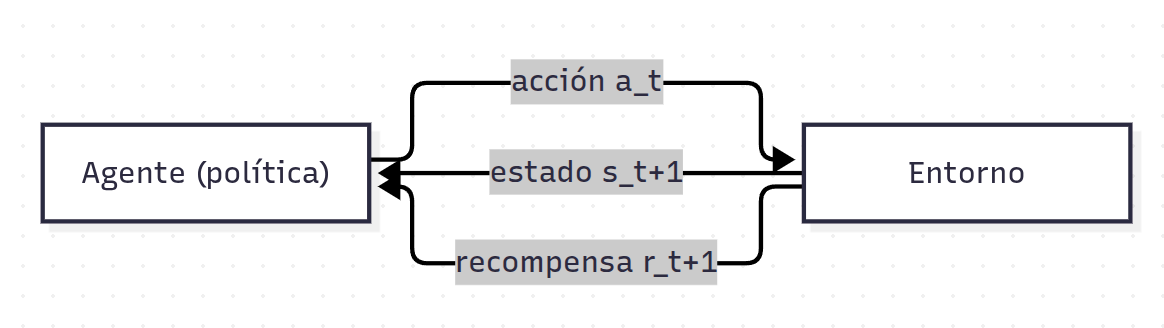

Lo que distingue a este paradigma: la señal es una **recompensa escalar y retrasada** (no la acción correcta), el agente **influye en los datos que recibe** con sus propias decisiones y debe resolver el **dilema exploración vs. explotación**: ¿repito lo que ya sé que funciona o pruebo algo nuevo que podría ser mejor?

**Ejemplos canónicos:** juegos (Atari con DQN, Mnih et al., 2015; Go con AlphaGo, Silver et al., 2016), robótica, control de inventarios y el ajuste de modelos de lenguaje con retroalimentación humana (RLHF). El algoritmo clásico *Q-learning* (Watkins, 1989) actualiza el valor de cada par estado-acción con $Q(s,a) \leftarrow Q(s,a) + \alpha\,[\,r + \gamma \max_{a'} Q(s',a') - Q(s,a)\,]$.

### Demo: bandido multibrazo con $\varepsilon$-greedy (NumPy puro)

El **bandido multibrazo** es el MDP más simple: un solo estado y $k$ acciones (brazos de una "tragamonedas"), cada una con una recompensa media **desconocida**. Es el escenario ideal para ver el dilema exploración/explotación. La estrategia **$\varepsilon$-greedy** elige, con probabilidad $1-\varepsilon$, el brazo con mayor valor estimado $Q(a)$ (explotar) y, con probabilidad $\varepsilon$, un brazo al azar (explorar). El valor se actualiza como **promedio incremental**:

$$Q_{n+1}(a) = Q_n(a) + \frac{1}{n}\,\big(R_n - Q_n(a)\big)$$

Replicamos el *testbed* de 10 brazos de Sutton & Barto (2018, cap. 2): las medias verdaderas $q_*(a) \sim \mathcal{N}(0,1)$ y cada recompensa $\sim \mathcal{N}(q_*(a), 1)$, promediando muchas ejecuciones independientes.

In [ ]:
# ============================================================
# APRENDIZAJE POR REFUERZO: bandido multibrazo epsilon-greedy (NumPy puro)
# ============================================================
def correr_bandido(epsilon, n_runs=300, n_pasos=1000, k=10, seed=SEED):
    """Simula n_runs bandidos de k brazos en paralelo (vectorizado).
    Devuelve la recompensa media por paso y el % de veces que se eligio el mejor brazo."""
    rng = np.random.default_rng(seed)
    q_real = rng.normal(0, 1, size=(n_runs, k))      # medias verdaderas (desconocidas para el agente)
    mejor = q_real.argmax(axis=1)                    # brazo optimo de cada ejecucion
    Q = np.zeros((n_runs, k))                        # estimaciones de valor
    N = np.zeros((n_runs, k))                        # veces que se eligio cada brazo
    idx = np.arange(n_runs)
    recompensa_media = np.zeros(n_pasos)
    pct_optimo = np.zeros(n_pasos)

    for t in range(n_pasos):
        explorar = rng.random(n_runs) < epsilon                          # explorar con prob. epsilon
        voraz = np.argmax(Q + 1e-9 * rng.random((n_runs, k)), axis=1)    # explotar (desempate aleatorio)
        accion = np.where(explorar, rng.integers(0, k, size=n_runs), voraz)
        r = rng.normal(q_real[idx, accion], 1.0)                         # recompensa ruidosa
        N[idx, accion] += 1
        Q[idx, accion] += (r - Q[idx, accion]) / N[idx, accion]          # promedio incremental
        recompensa_media[t] = r.mean()
        pct_optimo[t] = 100 * (accion == mejor).mean()
    return recompensa_media, pct_optimo

configuraciones = {0.0: "#dc2626", 0.01: "#16a34a", 0.1: "#2563eb"}
resultados = {eps: correr_bandido(eps) for eps in configuraciones}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for eps, color in configuraciones.items():
    rec, opt = resultados[eps]
    etiqueta = f"epsilon = {eps}" + (" (voraz puro)" if eps == 0 else "")
    axes[0].plot(rec, color=color, label=etiqueta)
    axes[1].plot(opt, color=color, label=etiqueta)
axes[0].set_title("Recompensa media por paso", fontweight="bold")
axes[0].set_xlabel("Pasos de interacción")
axes[0].set_ylabel("Recompensa media")
axes[1].set_title("% de veces que elige el mejor brazo", fontweight="bold")
axes[1].set_xlabel("Pasos de interacción")
axes[1].set_ylabel("% de acción óptima")
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

print("Recompensa media en los ultimos 100 pasos:")
for eps, (rec, opt) in resultados.items():
    print(f"  epsilon = {eps:<5} -> recompensa {rec[-100:].mean():.3f} | acción óptima {opt[-100:].mean():.1f}%")

---
> 💡 **Qué observar:** el agente **voraz puro** ($\varepsilon = 0$) suele quedarse "enganchado" con el primer brazo que parece bueno y nunca descubre el óptimo; explorar un poco ($\varepsilon = 0.01$ o $0.1$) cuesta recompensa al principio pero permite encontrar mejores brazos. Con $\varepsilon$ constante siempre se sigue explorando una fracción del tiempo, por lo que $\varepsilon = 0.1$ aprende más rápido pero no supera cierto porcentaje de acciones óptimas. Ningún dato traía la "respuesta correcta": el agente aprendió **solo de recompensas**.

## 5. Paradigmas Híbridos: Semi-supervisado y Auto-supervisado 🧬

Los tres paradigmas anteriores son los "puros". En la práctica, etiquetar datos es **caro** (requiere expertos, tiempo y dinero), por lo que han surgido enfoques intermedios:

| Paradigma | Idea | Ejemplo |
|---|---|---|
| **Semi-supervisado** | Pocas etiquetas + muchos datos sin etiquetar. La estructura de los datos sin etiquetar ayuda a propagar la información de las etiquetas | Clasificar miles de imágenes médicas con solo unas decenas diagnosticadas |
| **Auto-supervisado** | Las etiquetas **se generan a partir de los propios datos** mediante una tarea "pretexto" (predecir una palabra enmascarada, la siguiente palabra, o que dos vistas de la misma imagen sean similares) | Preentrenamiento de BERT (Devlin et al., 2018), GPT y SimCLR (Chen et al., 2020) |

El aprendizaje auto-supervisado es la base del **preentrenamiento de los grandes modelos de lenguaje**. Estrictamente se resuelve como un problema supervisado, pero con etiquetas obtenidas automáticamente y sin anotación humana.

### Demo: propagación de etiquetas con solo 10 etiquetas

Usamos el dataset sintético de "dos lunas" y le damos al algoritmo **solo 10 etiquetas** (5 por clase). Comparamos un *k*-NN que aprende únicamente de esas 10 con `LabelSpreading`, que además aprovecha la forma de los 290 puntos sin etiqueta.

In [ ]:
# ============================================================
# SEMI-SUPERVISADO: LabelSpreading con solo 10 etiquetas
# ============================================================
from sklearn.datasets import make_moons
from sklearn.semi_supervised import LabelSpreading

X_m, y_m = make_moons(n_samples=300, noise=0.08, random_state=SEED)

# Nos quedamos con 5 etiquetas por clase; el resto se marca como -1 (= sin etiqueta)
rng = np.random.default_rng(SEED)
idx_etiquetados = np.concatenate([rng.choice(np.where(y_m == c)[0], size=5, replace=False) for c in (0, 1)])
y_parcial = np.full_like(y_m, -1)
y_parcial[idx_etiquetados] = y_m[idx_etiquetados]
sin_etiqueta = y_parcial == -1

# (a) Solo supervisado: aprende unicamente de las 10 etiquetas
knn10 = KNeighborsClassifier(n_neighbors=3).fit(X_m[idx_etiquetados], y_m[idx_etiquetados])
acc_sup = (knn10.predict(X_m[sin_etiqueta]) == y_m[sin_etiqueta]).mean()

# (b) Semi-supervisado: usa tambien los 290 puntos sin etiqueta
ls = LabelSpreading(kernel="knn", n_neighbors=7, max_iter=200).fit(X_m, y_parcial)
acc_semi = (ls.transduction_[sin_etiqueta] == y_m[sin_etiqueta]).mean()

print(f"Accuracy sobre los 290 puntos sin etiqueta -> solo 10 etiquetas (k-NN): {acc_sup:.3f} | semi-supervisado: {acc_semi:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, pred, titulo in [(axes[0], knn10.predict(X_m), "Supervisado con 10 etiquetas (k-NN)"),
                         (axes[1], ls.transduction_, "Semi-supervisado (LabelSpreading)")]:
    ax.scatter(X_m[:, 0], X_m[:, 1], c=pred, cmap="coolwarm", s=18, alpha=0.7)
    ax.scatter(X_m[idx_etiquetados, 0], X_m[idx_etiquetados, 1], c=y_m[idx_etiquetados], cmap="coolwarm",
               s=150, edgecolor="black", marker="*", label="Puntos etiquetados")
    ax.set_title(titulo, fontweight="bold")
    ax.set_xlabel("Variable 1")
    ax.set_ylabel("Variable 2")
    ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

---
## 6. Tabla Comparativa de los Tres Paradigmas 📊

| Criterio | 🎓 Supervisado | 🔍 No supervisado | 🎮 Por refuerzo |
|---|---|---|---|
| **Datos de entrada** | Pares $(x_i, y_i)$: características + respuesta | Solo características $x_i$ | Experiencias $(s_t, a_t, r_{t+1}, s_{t+1})$ generadas por interacción |
| **Señal de aprendizaje** | Respuesta correcta (etiqueta) por ejemplo | Ninguna externa; la propia estructura de los datos | Recompensa escalar, a menudo retrasada |
| **Objetivo** | Minimizar el error de predicción sobre datos nuevos | Descubrir grupos, representaciones o densidades | Maximizar el retorno acumulado esperado |
| **Ejemplos de algoritmos** | *k*-NN, regresión lineal y logística, árboles, SVM, redes neuronales | K-Means, DBSCAN, jerárquico, PCA, Apriori | Q-learning, SARSA, *policy gradient*, DQN |
| **Ejemplos de aplicación** | Detección de spam, diagnóstico, precio de viviendas | Segmentación de clientes, compresión, canasta de mercado | Juegos, robótica, control, sistemas de recomendación interactivos |
| **Métricas típicas** | *Accuracy*, *precision/recall*, $F_1$, AUC, RMSE, $R^2$ | Inercia, *silhouette*, Davies-Bouldin, ARI (si hay *ground truth*) | Retorno acumulado, recompensa promedio, *regret* |
| **Principal dificultad** | Costo de etiquetar; sobreajuste | Evaluar sin respuesta correcta; interpretar | Exploración vs. explotación; muestras necesarias; estabilidad |

> 📌 **Regla práctica de decisión:** ¿hay etiquetas? → supervisado. ¿Solo hay datos y quiero estructura? → no supervisado. ¿Hay un agente que actúa y recibe retroalimentación? → refuerzo. ¿Hay pocas etiquetas y muchos datos? → semi-supervisado. En el [Cuaderno 02](02_Tipos_de_Problemas_en_ML.ipynb) llevamos esta decisión un paso más allá: identificar el **tipo de problema** concreto.

---
##### 🛠️ Práctica 1: ¿Cuántos vecinos? Memorizar no es aprender

En la Sección 2 vimos que un error de entrenamiento bajo **no garantiza** un buen modelo supervisado. Verifícalo con datos **ruidosos**, variando el hiperparámetro $k$ del clasificador *k*-NN (`make_moons` y `train_test_split` ya están importados):

1. Genera `X_n, y_n = make_moons(n_samples=300, noise=0.35, random_state=SEED)` y sepáralos en `Xn_tr, Xn_te, yn_tr, yn_te` con `test_size=0.3`, `stratify=y_n` y `random_state=SEED`.
2. Para cada $k$ en `[1, 5, 15, 45]` entrena un `KNeighborsClassifier(n_neighbors=k)` con los datos de entrenamiento y calcula el error de entrenamiento y el de prueba como $1 - \text{accuracy}$ (usa `.score`).
3. Guarda los resultados en un `DataFrame` llamado `tabla_k` (índice = $k$; columnas `err_train` y `err_test`), agrega la columna `brecha = err_test - err_train` e imprímelo.
4. Verifica con `assert` que con $k=1$ el error de entrenamiento es $0$ pero el de prueba es mayor, y que la brecha de $k=1$ supera a la de $k=15$.

In [ ]:
# Escribe tu código aquí

# X_n, y_n = make_moons(n_samples=300, noise=0.35, random_state=SEED)
# Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(...)
# filas = {}
# for k in [1, 5, 15, 45]:
#     modelo_k = KNeighborsClassifier(n_neighbors=k).fit(..., ...)
#     filas[k] = {"err_train": ..., "err_test": ...}
# tabla_k = pd.DataFrame(filas).T


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
# 1) Datos con mucho ruido: nada de "separacion limpia"
X_n, y_n = make_moons(n_samples=300, noise=0.35, random_state=SEED)
Xn_tr, Xn_te, yn_tr, yn_te = train_test_split(X_n, y_n, test_size=0.3, stratify=y_n, random_state=SEED)

# 2) Error de entrenamiento y de prueba para distintos k
filas = {}
for k in [1, 5, 15, 45]:
    modelo_k = KNeighborsClassifier(n_neighbors=k).fit(Xn_tr, yn_tr)
    filas[k] = {"err_train": 1 - modelo_k.score(Xn_tr, yn_tr),     # riesgo empirico (0-1)
                "err_test": 1 - modelo_k.score(Xn_te, yn_te)}      # estimacion del riesgo

# 3) Tabla con la brecha entre ambos errores
tabla_k = pd.DataFrame(filas).T
tabla_k["brecha"] = tabla_k["err_test"] - tabla_k["err_train"]
tabla_k.index.name = "k"
print(tabla_k.round(3))
print(f"\nMenor error de prueba con k = {tabla_k['err_test'].idxmin()}")

# 4) Con k = 1 el modelo memoriza el entrenamiento (cada punto es su propio vecino) pero generaliza peor
assert tabla_k.loc[1, "err_train"] == 0 and tabla_k.loc[1, "err_test"] > 0
assert tabla_k.loc[1, "brecha"] > tabla_k.loc[15, "brecha"]
print("k=1: error de entrenamiento 0 y gran brecha -> memoriza el ruido en lugar de aprender el patron.")
```
</details>

---


---
##### 🛠️ Práctica 2: Sin etiquetas: ¿cuántos grupos ve K-Means en Iris?

Ahora el mismo conjunto de flores, pero **sin dar la respuesta**: el objeto `iris` (cargado en la Sección 2) tiene las 4 medidas en `iris.data` y la especie real en `iris.target`. Haz de cuenta que no conoces la especie:

1. Define `X_iris = iris.data` (las 4 variables) y ajusta `KMeans(n_clusters=3, n_init=10, random_state=SEED)`; guarda las etiquetas en `grupos_iris`.
2. Usa `iris.target` **solo para auditar**: calcula `adjusted_rand_score(iris.target, grupos_iris)` e imprímelo.
3. Calcula el *silhouette* para $K = 2, 3, 4, 5, 6$ y guárdalo en un diccionario `sil_por_k`.
4. Imprime el $K$ con mayor *silhouette*. ¿Coincide con las 3 especies reales? Verifica con `assert` que el ARI del paso 2 supera $0.6$.

In [ ]:
# Escribe tu código aquí

# X_iris = iris.data
# km_iris = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_iris)
# grupos_iris = km_iris.labels_
# ari = ...
# sil_por_k = {}
# for k in range(2, 7):
#     ...


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
X_iris = iris.data                                           # 4 variables, SIN la especie
km_iris = KMeans(n_clusters=3, n_init=10, random_state=SEED).fit(X_iris)
grupos_iris = km_iris.labels_

# La especie real solo se usa para auditar (en un caso real no la tendriamos)
ari = adjusted_rand_score(iris.target, grupos_iris)
print(f"ARI de K-Means (K=3) vs. especies reales: {ari:.3f}")

sil_por_k = {}
for k in range(2, 7):
    etiquetas_k = KMeans(n_clusters=k, n_init=10, random_state=SEED).fit_predict(X_iris)
    sil_por_k[k] = silhouette_score(X_iris, etiquetas_k)
    print(f"K = {k} -> silhouette = {sil_por_k[k]:.3f}")

mejor_k = max(sil_por_k, key=sil_por_k.get)
print(f"\nEl silhouette prefiere K = {mejor_k}; las especies reales son 3.")
print("(Versicolor y virginica se solapan: la metrica interna ve 2 nubes, el conocimiento del dominio dice 3.)")

assert ari > 0.6
```
</details>

---


---
##### 🛠️ Práctica 3: Explorar vs. explotar: barrido de $\varepsilon$

En la Sección 4 comparamos tres valores de $\varepsilon$. Amplía el experimento con la función `correr_bandido(epsilon)` ya definida (devuelve la recompensa media por paso y el porcentaje de acción óptima, ambos como arreglos de 1000 pasos):

1. Para `epsilons = [0.0, 0.01, 0.05, 0.1, 0.3]` ejecuta `correr_bandido(eps)`.
2. Construye un `DataFrame` llamado `barrido` (índice = $\varepsilon$) con la recompensa media de los **primeros 100 pasos** (`rec_inicio`) y la de los **últimos 100 pasos** (`rec_final`).
3. Imprímelo e indica qué $\varepsilon$ gana al inicio y cuál al final (`.idxmax()`): ¿coinciden? ¿Por qué explorar mucho cuesta a largo plazo con $\varepsilon$ constante?
4. Verifica con `assert` que el agente voraz puro ($\varepsilon = 0$) **no** es el mejor al final.

In [ ]:
# Escribe tu código aquí

# epsilons = [0.0, 0.01, 0.05, 0.1, 0.3]
# filas = {}
# for eps in epsilons:
#     rec, opt = correr_bandido(eps)
#     filas[eps] = {"rec_inicio": ..., "rec_final": ...}
# barrido = pd.DataFrame(filas).T


<details>
<summary><b>💡 Haz clic aquí para ver la solución guiada...</b></summary>

```python
epsilons = [0.0, 0.01, 0.05, 0.1, 0.3]
filas = {}
for eps in epsilons:
    rec, opt = correr_bandido(eps)
    filas[eps] = {"rec_inicio": rec[:100].mean(),      # primeros 100 pasos
                  "rec_final": rec[-100:].mean()}      # ultimos 100 pasos

barrido = pd.DataFrame(filas).T
barrido.index.name = "epsilon"
print(barrido.round(3))

print(f"\nMejor epsilon al inicio: {barrido['rec_inicio'].idxmax()} | al final: {barrido['rec_final'].idxmax()}")
print("Con epsilon constante siempre se sigue explorando una fraccion del tiempo: eso tiene un costo a largo plazo.")

assert barrido["rec_final"].idxmax() != 0.0     # el voraz puro no gana al final
```
</details>

---


---
## Resumen y Puntos Clave 🎯

| Concepto | Mensaje Central |
|---|---|
| **Supervisado** | Aprende de pares $(x, y)$ minimizando el riesgo empírico; la calidad real se estima con datos no vistos |
| **No supervisado** | Sin respuesta correcta: busca estructura (K-Means minimiza la inercia $J$); evaluar exige criterios internos y juicio experto |
| **Por refuerzo** | Un agente aprende por ensayo y error maximizando el retorno; debe equilibrar **exploración y explotación** |
| **Semi-supervisado** | Aprovecha muchos datos sin etiqueta para propagar la información de pocas etiquetas |
| **Auto-supervisado** | Genera sus propias etiquetas desde los datos; base del preentrenamiento de los LLM |
| **Elección del paradigma** | Depende de la **retroalimentación disponible**, no del algoritmo preferido |

> 🚀 **Siguiente cuaderno:** [Tipos de Problemas en ML](02_Tipos_de_Problemas_en_ML.ipynb) — clasificación, regresión, clustering y reglas de asociación en casos ejecutables.

---
### 🧠 Autoevaluación

1. Un banco quiere detectar transacciones fraudulentas. ¿Qué paradigma usarías si tiene un histórico con fraudes confirmados? ¿Y si no tuviera ninguna etiqueta? Justifica.
2. En el bandido multibrazo, ¿por qué un agente con $\varepsilon = 0$ puede obtener peor resultado a largo plazo que uno con $\varepsilon = 0.1$, a pesar de "equivocarse" menos al inicio?
3. Explica con tus palabras por qué un error de entrenamiento bajo **no garantiza** un buen modelo supervisado. ¿Qué cantidad realmente nos interesa estimar?
4. Piensa en un ejemplo de tu entorno donde los datos sin etiqueta abunden pero las etiquetas sean costosas (por ejemplo, imágenes de cultivos en Boyacá). ¿Qué paradigma híbrido propondrías?

---
<div align="center">
  <p style="font-size: 0.9em; color: #64748b;">
    © 2026 <b>Universidad Santo Tomás — Seccional Tunja</b><br>
    <i>Especialización en Ciencia de Datos | Asignatura: Machine Learning</i>
  </p>
</div>